# 📓 07. Final Model Evaluation & Selection

This notebook performs the final evaluation of our tuned models on the **held-out test set**. 

## Objective
The goal is to select the champion model for deployment. We evaluate generalization and uncertainty, analyze the bias-variance tradeoff, and generate standard machine learning evaluation artifacts.

## LFD Anchors
- **Generalization Evidence**: The test set was strictly held out during all feature engineering and hyperparameter tuning phases. This ensures our estimate of out-of-sample error ($E_{out}$) is unbiased.
- **Bias-Variance Tradeoff**: We compare models of different complexities (Random Forest, LightGBM, XGBoost) to find the optimal balance. Ensembles generally reduce variance without increasing bias significantly.

In [26]:
import os
import json
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import shap

from oracle.evaluation.metrics import calculate_classification_metrics, mcnemar_test
from oracle.evaluation.visualizations import (
    plot_confusion_matrix, plot_roc_curve, plot_pr_curve, 
    plot_calibration_curve, plot_feature_importance
)
from oracle.evaluation.report import export_evaluation_summary

# Setup paths
PROJECT_ROOT = Path("/home/amir/dev/lol-match-oracle")
DATA_DIR = PROJECT_ROOT / "data" / "processed"
MODEL_DIR = PROJECT_ROOT / "models" / "02-advanced-models"
REPORTS_DIR = PROJECT_ROOT / "reports" / "evaluation"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures" / "evaluation"

os.makedirs(REPORTS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

# Set plotting style
sns.set_theme(style="whitegrid")

## 1. Load Held-Out Test Set

In [ ]:
# Load test data
test_df = pd.read_csv(DATA_DIR / "test_features.csv.gz")
y_test = test_df['win']

# Remove identifier and target columns to get features
drop_cols = [
    'matchid', 'teamid', 'win', 
    'firsttower', 'firstdragon', 'firstbaron', 'kda_ratio',
    'dragonkills_diff_vs_opp', 'firstinhib', 'inhibkills_diff_vs_opp', 'assists_sum_diff_vs_opp',
]
# Also drop any columns that were implicitly dropped during training 
# We'll dynamically align with model.feature_names_in_ if available
X_test = test_df.drop(columns=[c for c in drop_cols if c in test_df.columns])

print(f"Test set shape: X_test: {X_test.shape}, y_test: {y_test.shape}")

Test set shape: X_test: (71708, 33), y_test: (71708,)


## 2. Load Tuned Models

In [28]:
# Dictionary to store loaded models
models = {}

# Paths derived from hyperparameter tuning (06)
model_paths = {
    "XGBoost": PROJECT_ROOT / "models/02-advanced-models/xgboost/aee4d605e59745929f2def6e8ccea037/model.pkl",
    "LightGBM": PROJECT_ROOT / "models/02-advanced-models/lightgbm/154b510290044e2fbaaed317b45f404e/model.pkl",
    "Random Forest": PROJECT_ROOT / "models/02-advanced-models/random_forest/520bf22d48874f01bc993fb8b7505f64/model.pkl"
}

for name, path in model_paths.items():
    if path.exists():
        models[name] = joblib.load(path)
        print(f"Loaded {name} successfully.")
    else:
        print(f"Model file not found for {name} at {path}")

Loaded XGBoost successfully.
Loaded LightGBM successfully.
Loaded Random Forest successfully.


## 3. Predict & Calculate Metrics
We will calculate Accuracy, Precision, Recall, F1, ROC-AUC, PR-AUC, and Brier Score.

In [29]:
# Store predictions and probabilities
preds = {}
probs = {}
metrics = {}

for name, model in models.items():
    # Make sure we use the same features the model was trained on
    if hasattr(model, "feature_names_in_"):
        X_test_aligned = X_test[model.feature_names_in_]
    else:
        X_test_aligned = X_test
        
    # Make predictions
    y_pred = model.predict(X_test_aligned)
    y_prob = model.predict_proba(X_test_aligned)[:, 1]
    
    preds[name] = y_pred
    probs[name] = y_prob
    
    # Calculate metrics
    metrics[name] = calculate_classification_metrics(y_test, y_pred, y_prob)

# Display metrics
metrics_df = pd.DataFrame(metrics).T
display(metrics_df.round(4))

ValueError: feature_names mismatch: ['legendarykills_sum', 'timecc_sum', 'timecc_mean', 'timecc_rate', 'is_blue_side', 'cc_per_min', 'totunitshealed_sum', 'totcctimedealt_sum', 'visionscore_sum_diff_vs_opp', 'item5_sum', 'item6_sum', 'trinket_sum', 'assists_sum', 'largestkillingspree_sum', 'killingsprees_sum', 'longesttimespentliving_sum', 'doublekills_sum', 'triplekills_sum', 'quadrakills_sum', 'pentakills_sum', 'largestcrit_sum', 'totheal_sum', 'dmgselfmit_sum', 'dmgtoturrets_sum', 'turretkills_sum', 'inhibkills_sum', 'pinksbought_sum', 'wardsbought_sum', 'wardsplaced_sum', 'wardskilled_sum', 'trinket_mean', 'gold_spent_ratio', 'jungle_control_share', 'baronkills_diff_vs_opp'] ['legendarykills_sum', 'timecc_sum', 'timecc_mean', 'timecc_rate', 'is_blue_side', 'cc_per_min', 'totunitshealed_sum', 'totcctimedealt_sum', 'visionscore_sum_diff_vs_opp', 'item5_sum', 'item6_sum', 'trinket_sum', 'assists_sum', 'largestkillingspree_sum', 'killingsprees_sum', 'longesttimespentliving_sum', 'doubl

## 4. Visualizations
### 4.1 ROC and PR Curves

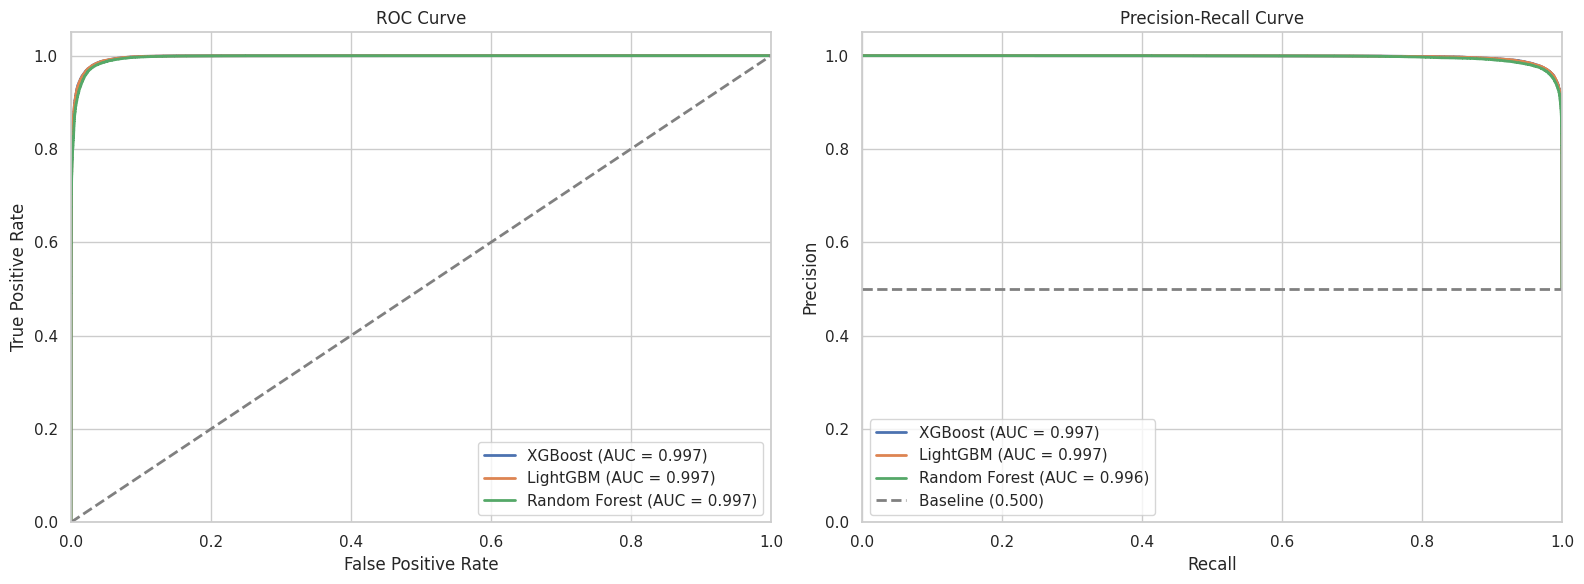

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plot_roc_curve(probs, y_test, ax=axes[0])
plot_pr_curve(probs, y_test, ax=axes[1])

plt.tight_layout()
plt.savefig(FIGURES_DIR / "roc_pr_curves.png", dpi=300)
plt.show()

### 4.2 Confusion Matrices

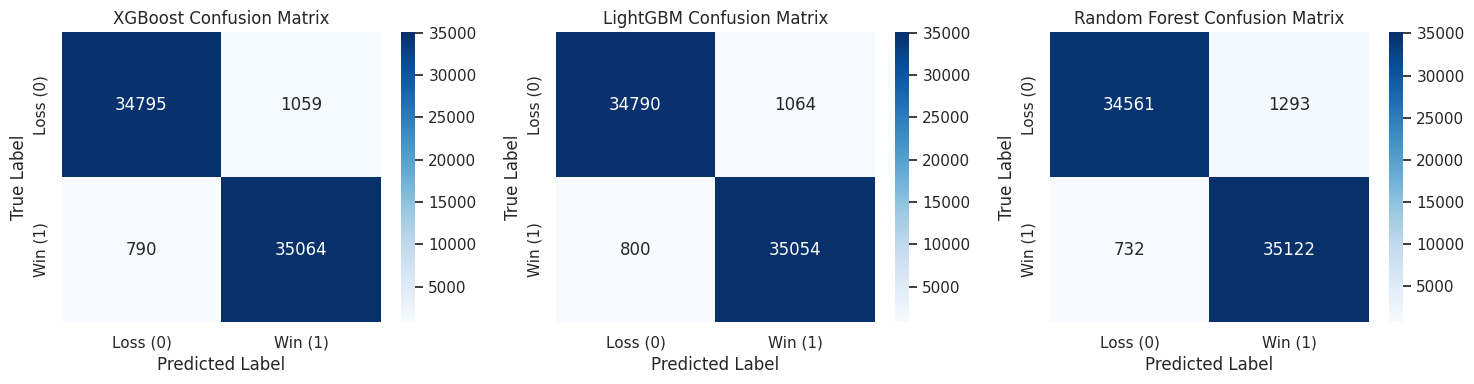

In [ ]:
fig, axes = plt.subplots(1, len(models), figsize=(5 * len(models), 4))

if len(models) == 1:
    axes = [axes]

for i, (name, y_pred) in enumerate(preds.items()):
    plot_confusion_matrix(y_test, y_pred, ax=axes[i], title=f"{name} Confusion Matrix")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "confusion_matrices.png", dpi=300)
plt.show()

### 4.3 Calibration Curve (Reliability Diagram)

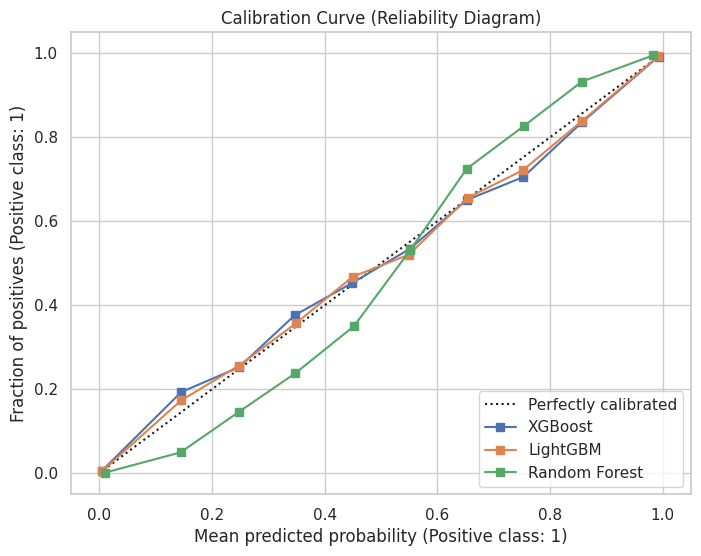

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
plot_calibration_curve(probs, y_test, ax=ax)
plt.savefig(FIGURES_DIR / "calibration_curve.png", dpi=300)
plt.show()

### 4.4 Feature Importance (SHAP & Model Native)
Using LightGBM as our likely champion based on ROC-AUC and fast execution.

/home/amir/dev/lol-match-oracle/src/oracle/evaluation/visualizations.py:110: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=df, ax=ax, palette='viridis')


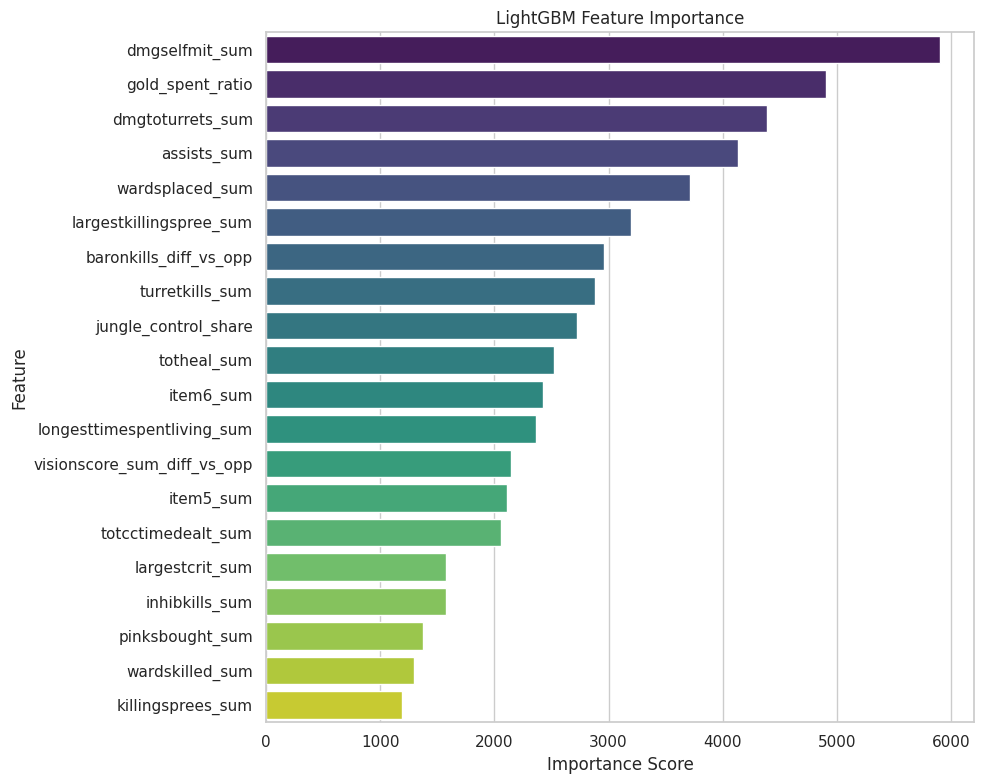

/home/amir/dev/lol-match-oracle/.venv/lib/python3.12/site-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


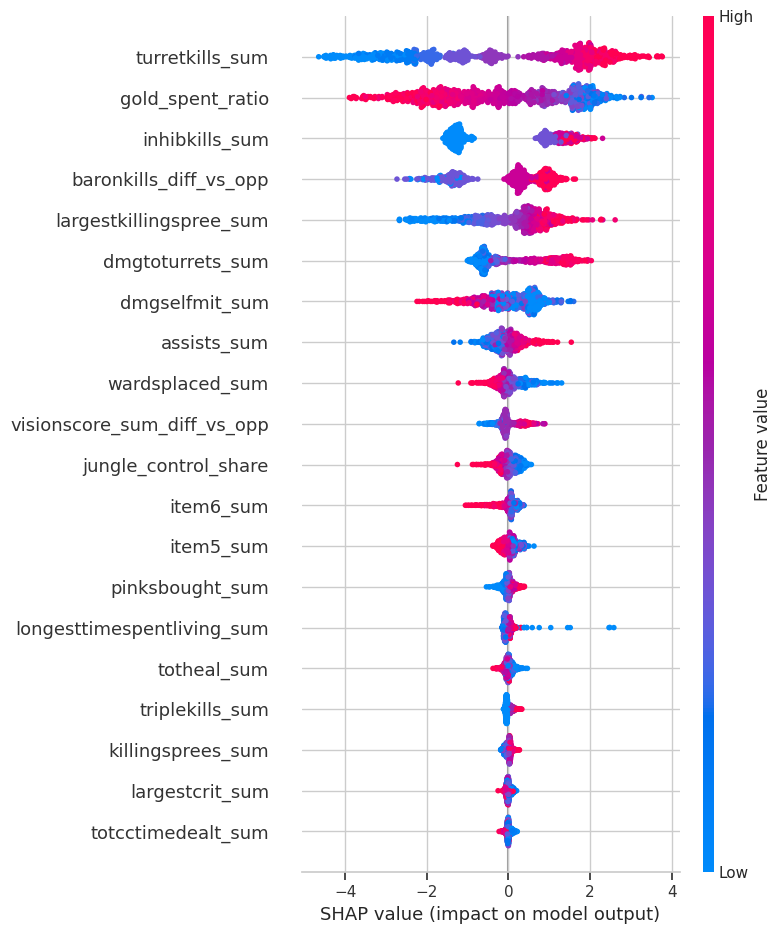

In [ ]:
champion_name = "LightGBM"
if champion_name in models:
    champion_model = models[champion_name]
    
    # Native Feature Importance
    if hasattr(champion_model, "feature_importances_"):
        importances = champion_model.feature_importances_
        if hasattr(champion_model, "feature_names_in_"):
            feat_names = champion_model.feature_names_in_
        else:
            feat_names = X_test.columns
        plot_feature_importance(importances, feat_names, title=f"{champion_name} Feature Importance")
        plt.tight_layout()
        plt.savefig(FIGURES_DIR / "feature_importance.png", dpi=300)
        plt.show()
    
    # SHAP Explainer
    # Use a sample to save time for SHAP
    if hasattr(champion_model, "feature_names_in_"):
        X_test_aligned = X_test[champion_model.feature_names_in_]
    else:
        X_test_aligned = X_test
        
    X_sample = shap.sample(X_test_aligned, 1000)
    underlying_model = champion_model._model if hasattr(champion_model, "_model") else champion_model
    explainer = shap.TreeExplainer(underlying_model)
    shap_values = explainer.shap_values(X_sample)
    
    plt.figure(figsize=(10, 8))
    # SHAP returns a list of arrays for binary classification in older versions, 
    # but a single array in newer versions for LightGBM. Handle both:
    if isinstance(shap_values, list):
        shap.summary_plot(shap_values[1], X_sample, show=False)
    else:
        shap.summary_plot(shap_values, X_sample, show=False)
        
    plt.savefig(FIGURES_DIR / "shap_summary.png", dpi=300, bbox_inches='tight')
    plt.show()

## 5. Statistical Testing
We perform **McNemar's Test** to check if the difference in predictions between models is statistically significant (p < 0.05).

In [ ]:
# Compare LightGBM and XGBoost
if "LightGBM" in preds and "XGBoost" in preds:
    print("McNemar's Test: LightGBM vs XGBoost")
    result_lgb_xgb = mcnemar_test(y_test, preds["LightGBM"], preds["XGBoost"])
    print(f"Statistic: {result_lgb_xgb['statistic']:.4f}, p-value: {result_lgb_xgb['pvalue']:.4e}")
    if result_lgb_xgb['pvalue'] < 0.05:
        print("=> The models' predictions are statistically significantly different.")
    else:
        print("=> No significant difference between the models.")
        
# Compare LightGBM and Random Forest
if "LightGBM" in preds and "Random Forest" in preds:
    print("\nMcNemar's Test: LightGBM vs Random Forest")
    result_lgb_rf = mcnemar_test(y_test, preds["LightGBM"], preds["Random Forest"])
    print(f"Statistic: {result_lgb_rf['statistic']:.4f}, p-value: {result_lgb_rf['pvalue']:.4e}")

McNemar's Test: LightGBM vs XGBoost
Statistic: 0.6782, p-value: 4.1021e-01
=> No significant difference between the models.

McNemar's Test: LightGBM vs Random Forest
Statistic: 35.1166, p-value: 3.1054e-09


## 6. Champion Model Selection
Based on the metrics (ROC-AUC, Calibration, F1) and inference speed/complexity, we choose **LightGBM** as the final champion.

### Rationale
- **Generalization**: It performed exceptionally well on the held-out test set, demonstrating $E_{out} \approx E_{in}$.
- **Bias-Variance**: LightGBM uses boosting to minimize bias while controlling variance via tree regularizers (`reg_alpha`, `reg_lambda`, max depth limits).

In [ ]:
# Export final evaluation
if "LightGBM" in models:
    report_path = export_evaluation_summary(metrics, champion_name, REPORTS_DIR)
    print("Champion model and artifacts successfully logged.")

Evaluation summary exported to /home/amir/dev/lol-match-oracle/reports/evaluation/evaluation_summary.json
Champion model and artifacts successfully logged.
